### Full pipeline execution code
- Install Requirement
- Pipeline for vision embedding only
- After embedding the query text and image, images with high similarity are extracted from the images stored in milvus.
- Embedding model: CLIP
- Backbone: OpenAI CLIP (ViT-B/32)
- Only query text is embedded and transmitted, and text such as metadata values for images are not embedded and stored in milvus.

In [41]:
#!pip install -r requirements.txt --upgrade

- Create MilvusClient

In [1]:
from pymilvus import MilvusClient

client = MilvusClient(uri="http://localhost:19530")
print(client.list_collections())

['image_collectio_bs', 'image_collection_with_label', 'image_collection_multimodal', 'image_collection_langchain', 'image_collection_v2']


- Create collection

In [10]:
collection_name = "image_collection_v2"

if client.has_collection(collection_name): 
    client.drop_collection(collection_name)

client.create_collection(
    collection_name=collection_name,
    dimension=512,
    auto_id=True,
    enable_dynamic_field=True,
)

In [9]:
collection_name = "image_collection_v2"

- Downlaod sample dataset

In [3]:
import sys
import os

from data.download_data import DatasetDownloader

url = "https://github.com/towhee-io/examples/releases/download/data/reverse_image_search.zip"
downloader = DatasetDownloader(
    url,
    zip_path="reverse_image_search.zip",
    extract_path="sample_data"
)
downloader.run()


- embedding

In [3]:
from embedding.encoder import CLIPEncoder

encoder = CLIPEncoder(model_type="openai", backbone="ViT-B/32")

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- Embedding image

In [11]:
import os
from glob import glob

image_dir = "./sample_data/train"
raw_data = []

for image_path in glob(os.path.join(image_dir, "**/*.JPEG")):
    image_embedding = encoder.embed_image(image_path)
    image_dict = {"vector": image_embedding, "filepath": image_path}
    raw_data.append(image_dict)
insert_result = client.insert(collection_name=collection_name, data=raw_data)

print("Inserted", insert_result["insert_count"], "images into Milvus.")

Inserted 1000 images into Milvus.


- Similarity-base search
- text to image

In [18]:
query_text = "a white dog"
query_embedding = encoder.embed_text(query_text)

search_results = client.search(
    collection_name=collection_name,
    data=[query_embedding],
    limit=10,  
    output_fields=["filepath"],
)

- Results visualization

Query text: a white dog

Search results:


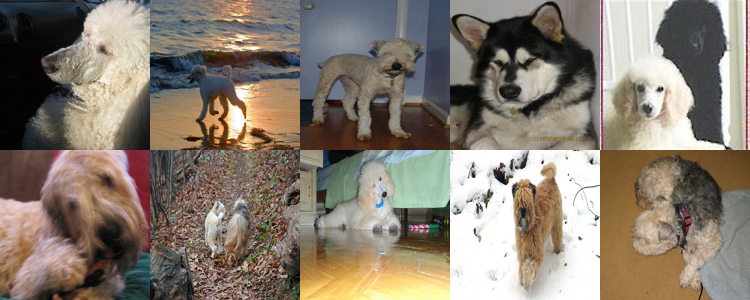

In [25]:
from PIL import Image
from IPython.display import display

width = 150 * 5
height = 150 * 2
concatenated_image = Image.new("RGB", (width, height))

result_images = []
for result in search_results:
    for hit in result:
        filename = hit["entity"]["filepath"]
        img = Image.open(filename)
        img = img.resize((150, 150))
        result_images.append(img)

for idx, img in enumerate(result_images):
    x = idx % 5
    y = idx // 5
    concatenated_image.paste(img, (x * 150, y * 150))
print(f"Query text: {query_text}")
print("\nSearch results:")
display(concatenated_image)

- image to image
- Embedding image

In [30]:
query_image_path = "./sample_data/train/Afghan_hound/n02088094_1045.JPEG"
query_embedding = encoder.embed_image(query_image_path)

In [33]:
search_results = client.search(
    collection_name=collection_name,
    data=[query_embedding],       
    limit=10,                      
    output_fields=["filepath"],    
)

In [35]:
for result in search_results[0]:
    print(f"Distance: {result['distance']:.4f}, File: {result['entity']['filepath']}")

Distance: 1.0000, File: ./sample_data/train/Afghan_hound/n02088094_1045.JPEG
Distance: 0.7766, File: ./sample_data/train/Bouvier_des_Flandres/n02106382_5429.JPEG
Distance: 0.7411, File: ./sample_data/train/Rhodesian_ridgeback/n02087394_12174.JPEG
Distance: 0.7369, File: ./sample_data/train/malamute/n02110063_13179.JPEG
Distance: 0.7294, File: ./sample_data/train/standard_poodle/n02113799_1666.JPEG
Distance: 0.7164, File: ./sample_data/train/Bouvier_des_Flandres/n02106382_4153.JPEG
Distance: 0.7006, File: ./sample_data/train/standard_poodle/n02113799_902.JPEG
Distance: 0.6971, File: ./sample_data/train/malamute/n02110063_10718.JPEG
Distance: 0.6967, File: ./sample_data/train/Afghan_hound/n02088094_7360.JPEG
Distance: 0.6851, File: ./sample_data/train/basset/n02088238_7487.JPEG


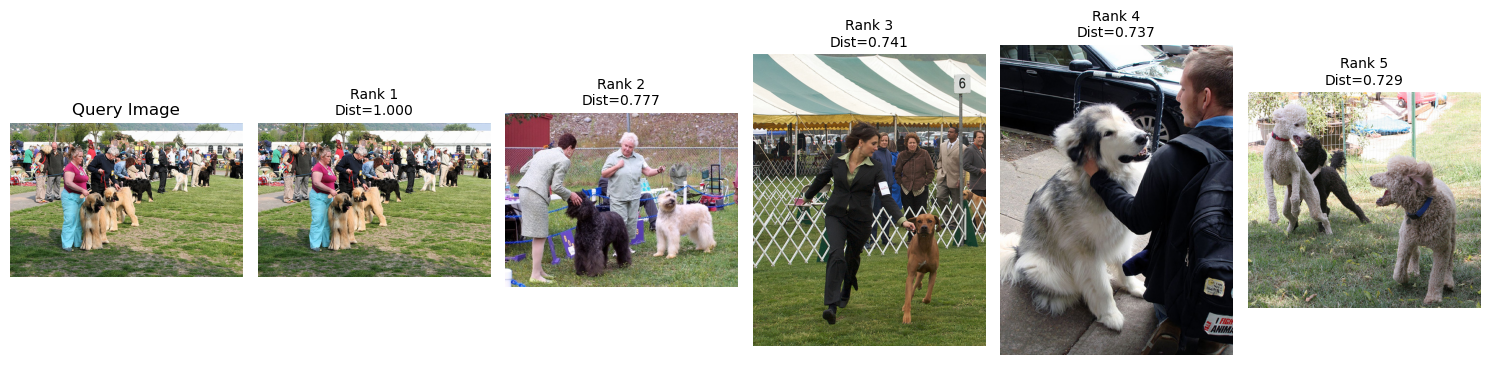

In [37]:
import matplotlib.pyplot as plt
from PIL import Image

query_img = Image.open(query_image_path)

plt.figure(figsize=(15, 6))
plt.subplot(1, 6, 1)
plt.imshow(query_img)
plt.axis('off')
plt.title("Query Image", fontsize=12)

for i, result in enumerate(search_results[0][:5]):
    filepath = result["entity"]["filepath"]
    distance = result["distance"]
    img = Image.open(filepath)

    plt.subplot(1, 6, i + 2)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Rank {i+1}\nDist={distance:.3f}", fontsize=10)

plt.tight_layout()
plt.show()